## Importing Modules

In [9]:
import pandas as pd 
import numpy as np
from matplotlib import pyplot as plt 
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import joblib

In [10]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.evaluate_model import Evaluate_model

## Loading the Dataset


In [11]:
df = pd.read_csv('../data/processed/hour_features.csv')
df.head()

,datetime,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,...,lag_1,lag_24,lag_168,rolling_mean,rolling_median,rolling_std,is_peak_hour,weather_hr,temp_hr,temp_hum
0,2011-01-08 07:00:00,1,0,1,7,0,6,0,2,0.16,...,2.0,84.0,16.0,60.083333,50.5,56.721989,1,14,1.12,0.1184
1,2011-01-08 08:00:00,1,0,1,8,0,6,0,3,0.16,...,9.0,210.0,40.0,51.958333,44.5,47.536237,1,24,1.28,0.1488
2,2011-01-08 09:00:00,1,0,1,9,0,6,0,3,0.16,...,15.0,134.0,32.0,47.208333,37.5,44.585998,1,27,1.44,0.1488
3,2011-01-08 10:00:00,1,0,1,10,0,6,0,2,0.18,...,20.0,63.0,13.0,47.125000,37.5,44.557059,0,20,1.80,0.1440
4,2011-01-08 11:00:00,1,0,1,11,0,6,0,2,0.20,...,61.0,67.0,1.0,46.916667,37.5,44.471698,0,22,2.20,0.1380


## Time Series Split

Unlike random train-test splitting, TimeSeriesSplit preserves the chronological order of observations. Each fold trains on past data and evaluates on future data, preventing data leakage and providing a realistic estimate of model performance in real-world forecasting scenarios.

In [12]:
X = df.drop(columns=['cnt'] , axis=1)
y = df['cnt']

tscv = TimeSeriesSplit(n_splits=5)

for fold , (train_idx , test_idx) in enumerate(tscv.split(X)):
    print(f"Fold {fold}:")
    print(f"  Train Indices: {train_idx[0]} -> {train_idx[-1]}")
    print(f"  Test Indices:  {test_idx[0]}  -> {test_idx[-1]}\n")

Fold 0:
  Train Indices: 0 -> 2870
  Test Indices:  2871  -> 5738

Fold 1:
  Train Indices: 0 -> 5738
  Test Indices:  5739  -> 8606

Fold 2:
  Train Indices: 0 -> 8606
  Test Indices:  8607  -> 11474

Fold 3:
  Train Indices: 0 -> 11474
  Test Indices:  11475  -> 14342

Fold 4:
  Train Indices: 0 -> 14342
  Test Indices:  14343  -> 17210



### Visualize the splits

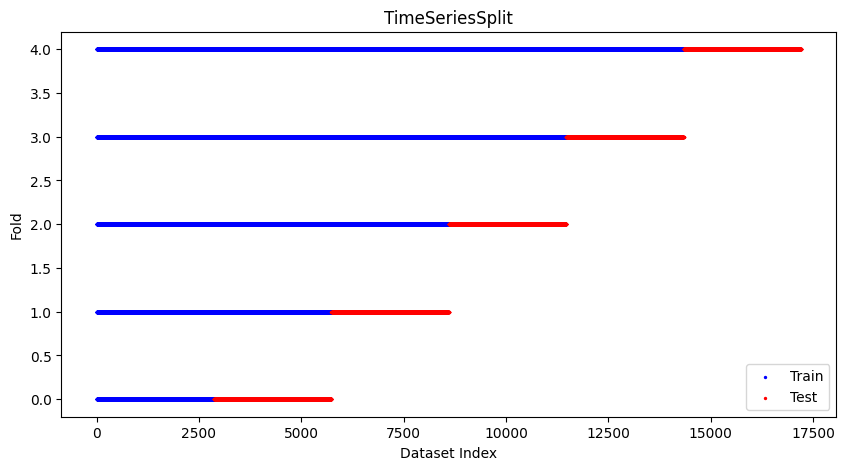

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):

    plt.scatter(train_idx,
                [fold]*len(train_idx),
                color="blue",
                s=2)

    plt.scatter(test_idx,
                [fold]*len(test_idx),
                color="red",
                s=2)

plt.xlabel("Dataset Index")
plt.ylabel("Fold")
plt.title("TimeSeriesSplit")
plt.legend(['Train' , 'Test'])
plt.show()

## Building Baseline Models

### Baseline model 1 : Predicting yesterday's bike demand

In [14]:
y_true = df["cnt"]
y_pred = df["lag_24"]

mae1 = mean_absolute_error(
    y_true,
    y_pred
)

rmse1 = np.sqrt(
    mean_squared_error(
        y_true,
        y_pred
    )
)

r21 = r2_score(
    y_true,
    y_pred
)

print("MAE :", mae1)
print("RMSE:", rmse1)
print("R²  :", r21)

MAE : 65.36029283597699
RMSE: 110.52741336266935
R²  : 0.6300429720034595


### Baseline model 2 : Predicting Average Demand of Same Hour

In [15]:
hr_mean = (
    df.groupby('hr')['cnt'].mean()
)
print(hr_mean)

hr
0      54.356546
1      33.617318
2      23.007062
3      11.740634
4       6.409289
5      20.050704
6      76.648536
7     213.530556
8     361.150000
9     220.618056
10    174.884722
11    209.602778
12    255.029126
13    255.375346
14    242.610803
15    252.952909
16    314.188105
17    464.467497
18    428.418863
19    313.676838
20    227.707351
21    173.578363
22    132.302358
23     88.507628
Name: cnt, dtype: float64


In [16]:
df_2 = pd.DataFrame({
    'hr' : df['hr'],
    'cnt' : df['cnt'],
    'mean' : df['hr'].map(hr_mean)
})

df_2.head()

,hr,cnt,mean
0,7,9,213.530556
1,8,15,361.150000
2,9,20,220.618056
3,10,61,174.884722
4,11,62,209.602778


In [17]:
y_true = df_2['cnt']
y_pred = df_2['mean']

mae2 = mean_absolute_error(
    y_true,
    y_pred
)

rmse2 = np.sqrt(
    mean_squared_error(
        y_true,
        y_pred
    )
)

r22 = r2_score(
    y_true,
    y_pred
)

print("MAE :", mae2)
print("RMSE:", rmse2)
print("R²  :", r22)

MAE : 87.74303041356873
RMSE: 127.68479550610084
R²  : 0.5062698602709195


### Comparing baseline Models

In [18]:
results = pd.DataFrame({
    "Model":[
        "Naive-24",
        "Hour Mean"
    ],
    "MAE":[
        mae1,
        mae2
    ],
    "RMSE":[
        rmse1,
        rmse2
    ],
    "R2":[
        r21,
        r22
    ]
})

results

,Model,MAE,RMSE,R2
0,Naive-24,65.360293,110.527413,0.630043
1,Hour Mean,87.743030,127.684796,0.506270


## Training Machine Learning Models

In [19]:
X = df.drop(columns=['cnt','datetime'] , axis=1)
y = df['cnt']

### 1.Linear Regression


In [20]:
# Linear Regression 

linear = LinearRegression()

linear_results = Evaluate_model(linear , X , y)
linear_results

{'MAE': 52.1651581525329, 'RMSE': 74.96132217417889, 'R2': 0.8215704394829977}

### 2.Ridge Regression
Some features are highly correlated (for example, temp and atemp). Ridge reduces the impact of multicollinearity and can improve generalization.

In [21]:
# Ridge Regression

ridge = Ridge(alpha=1.0)

ridge_results = Evaluate_model(ridge , X , y)
ridge_results

{'MAE': 51.4209859572313, 'RMSE': 74.14233714793453, 'R2': 0.8264916943443149}

### 3.Random Forest Regressor
Random Forest captures non-linear relationships and feature interactions without requiring extensive preprocessing.

In [22]:
# Random Forest

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_results = Evaluate_model(rf , X , y)
rf_results

{'MAE': 32.78722942817294, 'RMSE': 53.65689401364184, 'R2': 0.9064351988001651}

### 4.XGBoost Regressor

In [23]:
# XG Boost 

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_results = Evaluate_model(xgb,X,y)
xgb_results

{'MAE': 30.18517951965332, 'RMSE': 47.32738832365068, 'R2': 0.9256942391395568}

### 5.LightGBM Regressor
LightGBM is optimized for speed and efficiency. It often trains faster than XGBoost while achieving comparable or better performance on large tabular datasets.

In [24]:
# LightGBM

lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

lgbm_results = Evaluate_model(lgbm,X,y)
lgbm_results

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000385 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2338
[LightGBM] [Info] Number of data points in the train set: 2871, number of used features: 27
[LightGBM] [Info] Start training from score 97.387321
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000204 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2414
[LightGBM] [Info] Number of data points in the train set: 5739, number of used features: 27
[LightGBM] [Info] Start training from score 143.179648
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000381 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total B

{'MAE': 29.61559359635562,
 'RMSE': 46.372825460961074,
 'R2': 0.9289519954346398}

### Compare All Models

In [25]:
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Ridge",
        "Random Forest",
        "XGBoost",
        "LightGBM"
    ],

    "MAE":[
        linear_results["MAE"],
        ridge_results["MAE"],
        rf_results["MAE"],
        xgb_results["MAE"],
        lgbm_results["MAE"]
    ],

    "RMSE":[
        linear_results["RMSE"],
        ridge_results["RMSE"],
        rf_results["RMSE"],
        xgb_results["RMSE"],
        lgbm_results["RMSE"]
    ],

    "R2":[
        linear_results["R2"],
        ridge_results["R2"],
        rf_results["R2"],
        xgb_results["R2"],
        lgbm_results["R2"]
    ]

})

results.sort_values("MAE")

,Model,MAE,RMSE,R2
4,LightGBM,29.615594,46.372825,0.928952
3,XGBoost,30.185180,47.327388,0.925694
2,Random Forest,32.787229,53.656894,0.906435
1,Ridge,51.420986,74.142337,0.826492
0,Linear Regression,52.165158,74.961322,0.821570


### Hence the best model is LightGBM 

In [26]:
best_model = lgbm

best_model.fit(X,y)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000779 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2448
[LightGBM] [Info] Number of data points in the train set: 17211, number of used features: 28
[LightGBM] [Info] Start training from score 190.761374


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [28]:
joblib.dump(
    best_model,
    '../models/ridewise_model.joblib'
)

['../models/ridewise_model.joblib']